# AAI-540 Group Project
## Machine Learning-Based RF Intrusion Detection System

### Group 6

This project develops a supervised multi-class machine learning system
for classifying radiofrequency (RF) activity using RF spectrogram images.

The dataset contains six RF activity classes:

- Benign
- Broadband Jam
- Narrowband Jam
- Human
- Machine
- Wildlife

The objective is to train and evaluate an image classification model
capable of distinguishing among these RF activity categories.

The project supports a larger MLOps workflow that will include data
preparation, model training, evaluation, deployment, and monitoring.

In [17]:
# ============================================
# Environment Setup
# ============================================

import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Environment setup complete.")

TensorFlow version: 2.20.0
Environment setup complete.


In [18]:
# ============================================
# Download Dataset from Kaggle
# ============================================

!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download(
    "hector484/unified-multi-class-rf-intrusion-dataset"
)

dataset_dir = os.path.join(path, "unified_dataset")

print("Dataset downloaded successfully.")
print("Dataset directory:")
print(dataset_dir)

Using Colab cache for faster access to the 'unified-multi-class-rf-intrusion-dataset' dataset.
Dataset downloaded successfully.
Dataset directory:
/kaggle/input/unified-multi-class-rf-intrusion-dataset/unified_dataset


In [19]:
import kagglehub

path = kagglehub.dataset_download(
    "hector484/unified-multi-class-rf-intrusion-dataset"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'unified-multi-class-rf-intrusion-dataset' dataset.
Dataset downloaded to:
/kaggle/input/unified-multi-class-rf-intrusion-dataset


In [20]:
# ============================================
# Inspect Dataset Structure
# ============================================

print("Top-level dataset contents:\n")

for item in sorted(os.listdir(dataset_dir)):
    item_path = os.path.join(dataset_dir, item)

    if os.path.isdir(item_path):
        print(f"[DIR]  {item}")
    else:
        print(f"[FILE] {item}")

Top-level dataset contents:

[FILE] dataset_verification.png
[DIR]  test
[DIR]  train
[DIR]  val


In [21]:
# ============================================
# Define Dataset Splits
# ============================================

train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
test_dir = os.path.join(dataset_dir, "test")

print("Training directory:", train_dir)
print("Validation directory:", val_dir)
print("Testing directory:", test_dir)

Training directory: /kaggle/input/unified-multi-class-rf-intrusion-dataset/unified_dataset/train
Validation directory: /kaggle/input/unified-multi-class-rf-intrusion-dataset/unified_dataset/val
Testing directory: /kaggle/input/unified-multi-class-rf-intrusion-dataset/unified_dataset/test


In [22]:
# ============================================
# Identify RF Classes
# ============================================

class_names = sorted([
    folder
    for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print(f"Number of classes: {len(class_names)}\n")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Number of classes: 6

0: Benign
1: Broadband_Jam
2: Human
3: Machine
4: Narrowband_Jam
5: Wildlife


In [23]:
# ============================================
# Count Images by Split and Class
# ============================================

def count_images(directory):
    counts = {}

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)

        counts[class_name] = len([
            file
            for file in os.listdir(class_dir)
            if file.lower().endswith(".png")
        ])

    return counts


train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

print("Class Distribution\n")

print(f"{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 58)

for class_name in class_names:
    train_count = train_counts[class_name]
    val_count = val_counts[class_name]
    test_count = test_counts[class_name]
    total = train_count + val_count + test_count

    print(
        f"{class_name:<20}"
        f"{train_count:>8}"
        f"{val_count:>8}"
        f"{test_count:>8}"
        f"{total:>8}"
    )

Class Distribution

Class                   Train      Val     Test    Total
----------------------------------------------------------
Benign                  2800     600     600    4000
Broadband_Jam           2800     600     600    4000
Human                   2800     600     600    4000
Machine                 2800     600     600    4000
Narrowband_Jam          2800     600     600    4000
Wildlife                2800     600     600    4000


In [24]:
total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())

total_images = total_train + total_val + total_test

print("Dataset Summary")
print("-----------------")
print(f"Training images:   {total_train:,}")
print(f"Validation images: {total_val:,}")
print(f"Testing images:    {total_test:,}")
print(f"Total images:      {total_images:,}")

Dataset Summary
-----------------
Training images:   16,800
Validation images: 3,600
Testing images:    3,600
Total images:      24,000


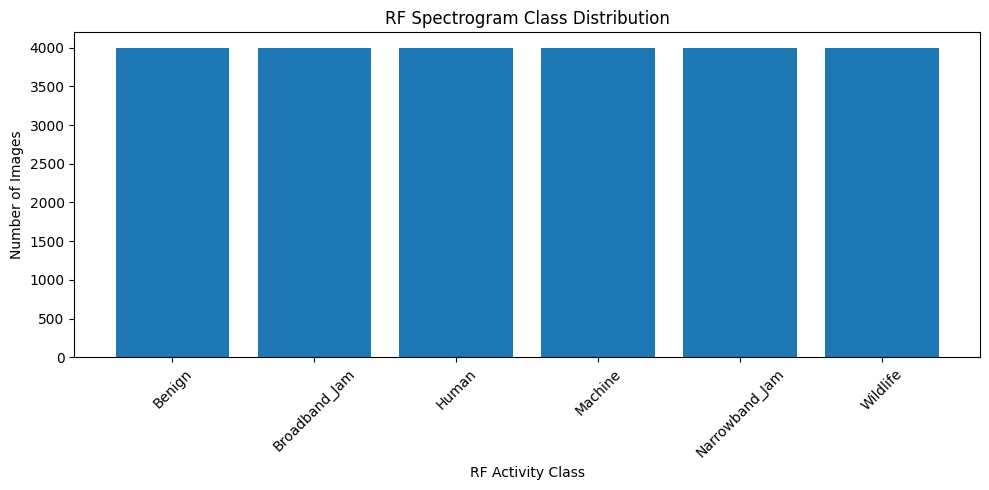

In [25]:
# ============================================
# Visualize Class Distribution
# ============================================

totals_by_class = [
    train_counts[c] + val_counts[c] + test_counts[c]
    for c in class_names
]

plt.figure(figsize=(10, 5))

plt.bar(class_names, totals_by_class)

plt.title("RF Spectrogram Class Distribution")
plt.xlabel("RF Activity Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

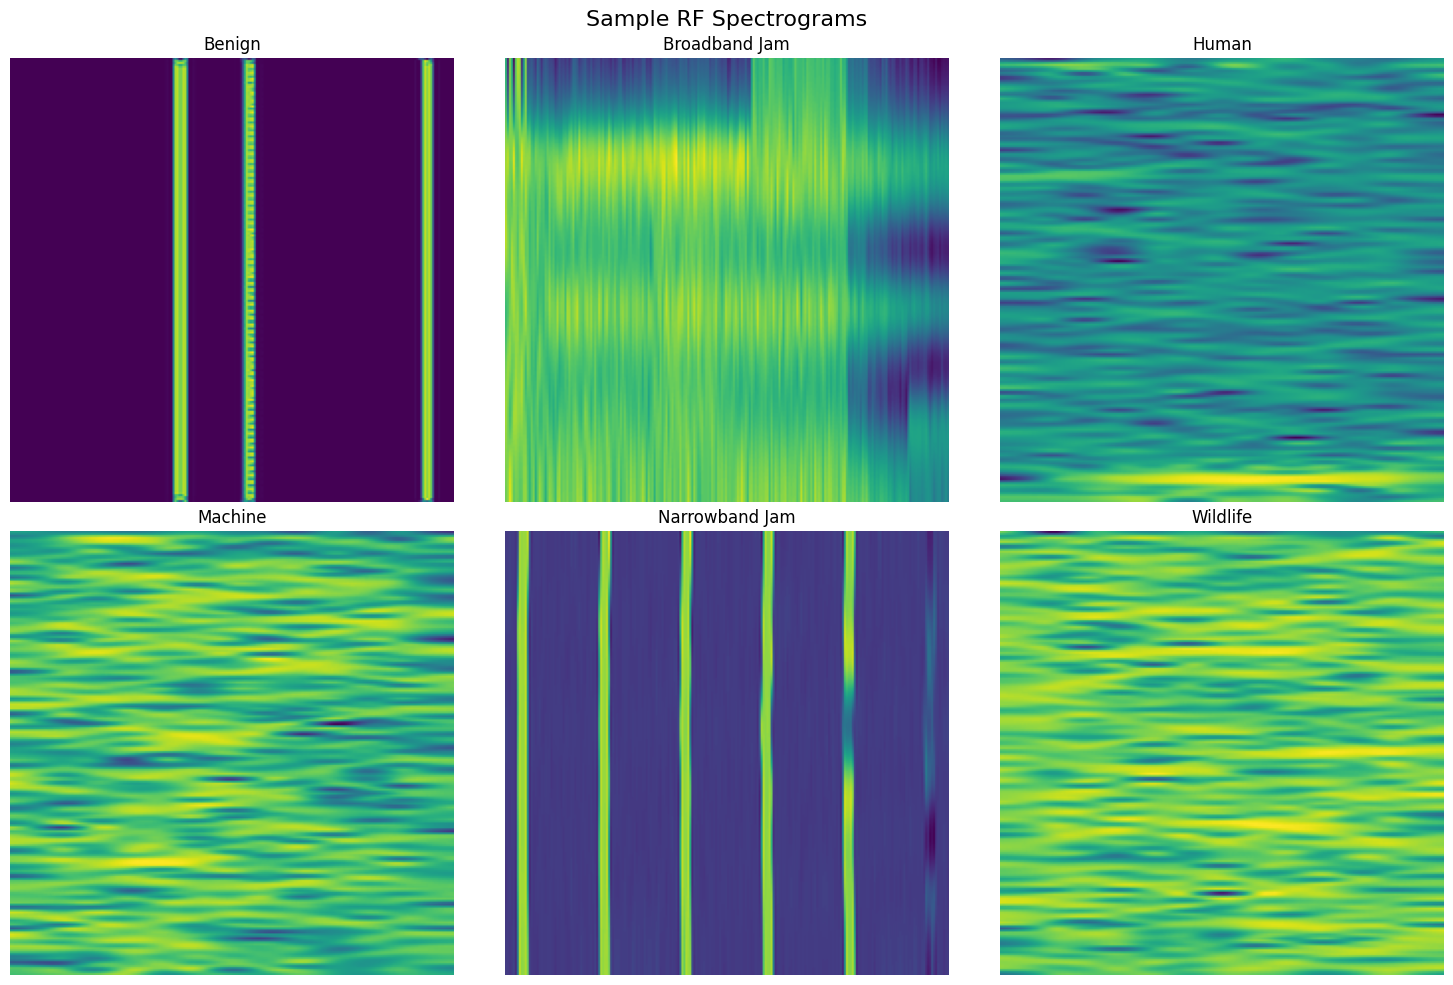

In [26]:
# ============================================
# Display One Spectrogram from Each Class
# ============================================

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):

    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file
        for file in os.listdir(class_dir)
        if file.lower().endswith(".png")
    ]

    sample_file = random.choice(image_files)

    image_path = os.path.join(class_dir, sample_file)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("_", " "))
    plt.axis("off")

plt.suptitle("Sample RF Spectrograms", fontsize=16)
plt.tight_layout()

plt.show()

In [27]:
# ============================================
# Inspect Spectrogram Image Properties
# ============================================

sample_class = class_names[0]

sample_file = os.listdir(
    os.path.join(train_dir, sample_class)
)[0]

sample_path = os.path.join(
    train_dir,
    sample_class,
    sample_file
)

sample_image = Image.open(sample_path)

print("Class:", sample_class)
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)
print("Image format:", sample_image.format)

Class: Benign
Image size: (224, 224)
Image mode: L
Image format: PNG


In [28]:
# ============================================
# Check Image Dimensions
# ============================================

image_sizes = Counter()
image_modes = Counter()

sample_limit = 500

sampled = 0

for class_name in class_names:

    class_dir = os.path.join(train_dir, class_name)

    for file in os.listdir(class_dir):

        if not file.lower().endswith(".png"):
            continue

        image_path = os.path.join(class_dir, file)

        with Image.open(image_path) as img:
            image_sizes[img.size] += 1
            image_modes[img.mode] += 1

        sampled += 1

        if sampled >= sample_limit:
            break

    if sampled >= sample_limit:
        break


print("Sampled images:", sampled)

print("\nImage dimensions:")
for size, count in image_sizes.items():
    print(size, ":", count)

print("\nImage modes:")
for mode, count in image_modes.items():
    print(mode, ":", count)

Sampled images: 500

Image dimensions:
(224, 224) : 500

Image modes:
L : 500


In [29]:
# ============================================
# Create TensorFlow Image Datasets
# ============================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 16800 files belonging to 6 classes.
Found 3600 files belonging to 6 classes.
Found 3600 files belonging to 6 classes.


In [30]:
print("Classes:")
print(train_ds.class_names)

Classes:
['Benign', 'Broadband_Jam', 'Human', 'Machine', 'Narrowband_Jam', 'Wildlife']


In [31]:
# ============================================
# Optimize Input Pipeline
# ============================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("TensorFlow datasets ready.")

TensorFlow datasets ready.
